In [6]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df=pd.read_csv('../data/processed/train.csv')

In [8]:
df

,kyc_verified,account_age_days,transaction_amount,hour,day,weekday,channel_atm,channel_mobile,channel_pos,channel_web,avg_txn_per_customer,txns_count_per_customer,amt_deviation,high_amount_flag,is_night,is_weekend,is_fraud
0,1,0.782201,0.022567,13,9,5,0,0,0,1,38947.000000,7,-31440.000000,0,0,0,0
1,0,0.619271,0.796280,17,8,4,0,1,0,0,88983.571429,7,139762.428571,1,0,0,0
2,1,0.439946,0.033241,3,12,1,0,0,0,1,9188.200000,10,1370.800000,0,1,0,0
3,1,0.519906,0.210264,4,16,5,0,1,0,0,15292.000000,8,45886.000000,0,1,0,0
4,1,0.588491,0.032335,14,16,5,1,0,0,0,9706.500000,8,593.500000,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,0.800937,0.014982,23,4,0,0,0,1,0,59560.344545,11,-54222.344545,0,1,0,0
3996,1,0.741051,0.657760,21,6,2,0,1,0,0,35242.571429,7,153894.428571,0,0,0,1
3997,1,0.146203,0.141888,7,22,4,0,1,0,0,58493.000000,9,-16867.000000,0,0,0,0
3998,0,0.612245,0.048803,8,9,5,0,1,0,0,46847.300000,10,-31838.300000,0,0,0,1


In [9]:

# Separate features and target
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Load test data for evaluation
test_df = pd.read_csv('../data/processed/test.csv')
X_test = test_df.drop('is_fraud', axis=1)
y_test = test_df['is_fraud']

In [10]:

def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"\n{model_name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()



# Decision Tree


Decision Tree Results:
Accuracy: 0.8340
Precision: 0.1774
Recall: 0.2558
F1 Score: 0.2095


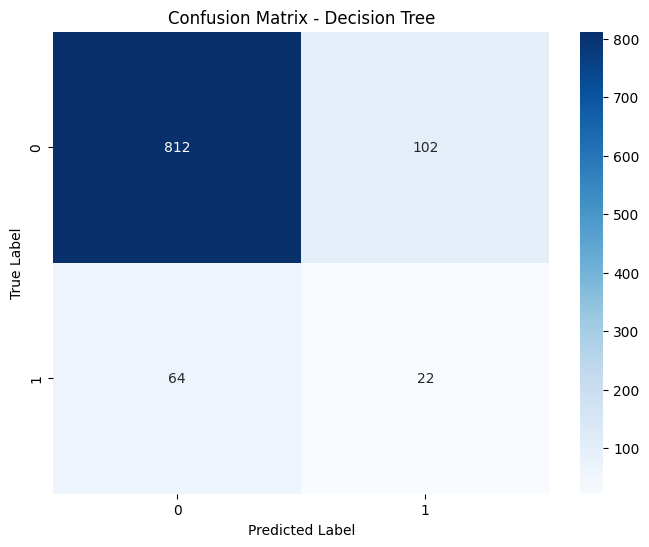

In [11]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X, y)
dt_pred = dt_model.predict(X_test)
evaluate_model(y_test, dt_pred, "Decision Tree")

# Random Forest


Random Forest Results:
Accuracy: 0.9130
Precision: 0.3333
Recall: 0.0116
F1 Score: 0.0225


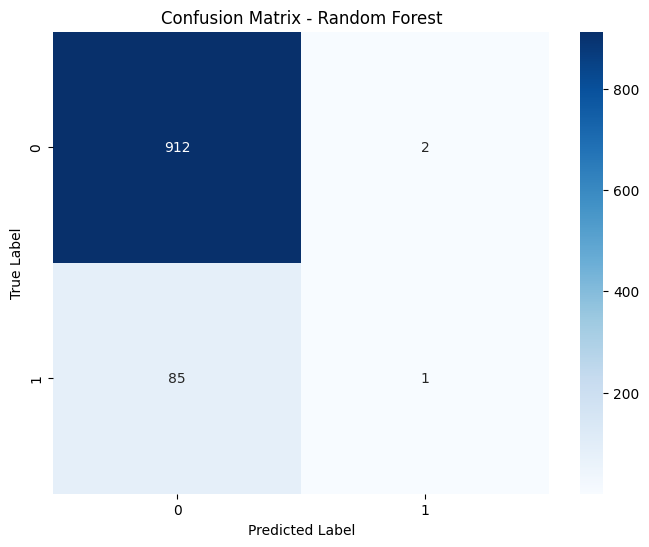

In [12]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)
rf_pred = rf_model.predict(X_test)
evaluate_model(y_test, rf_pred, "Random Forest")

# XGBoost


XGBoost Results:
Accuracy: 0.9030
Precision: 0.1333
Recall: 0.0233
F1 Score: 0.0396


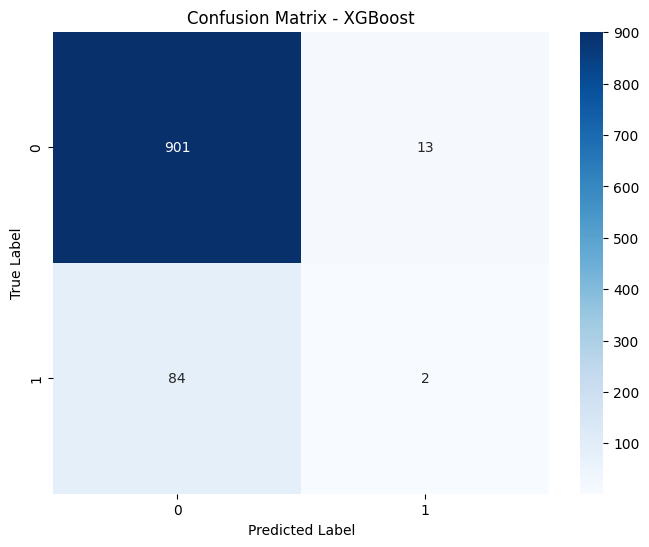

In [13]:
# XGBoost
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X, y)
xgb_pred = xgb_model.predict(X_test)
evaluate_model(y_test, xgb_pred, "XGBoost")

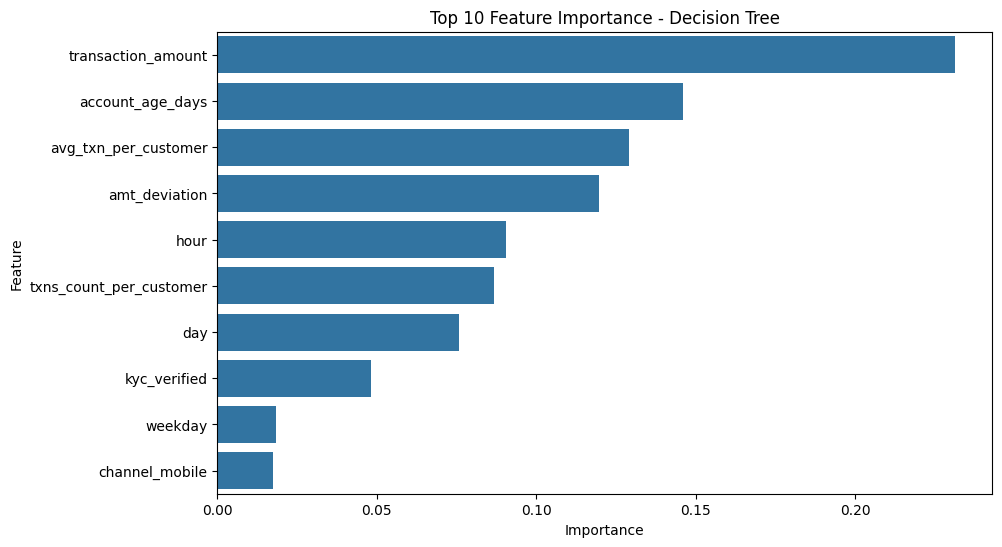

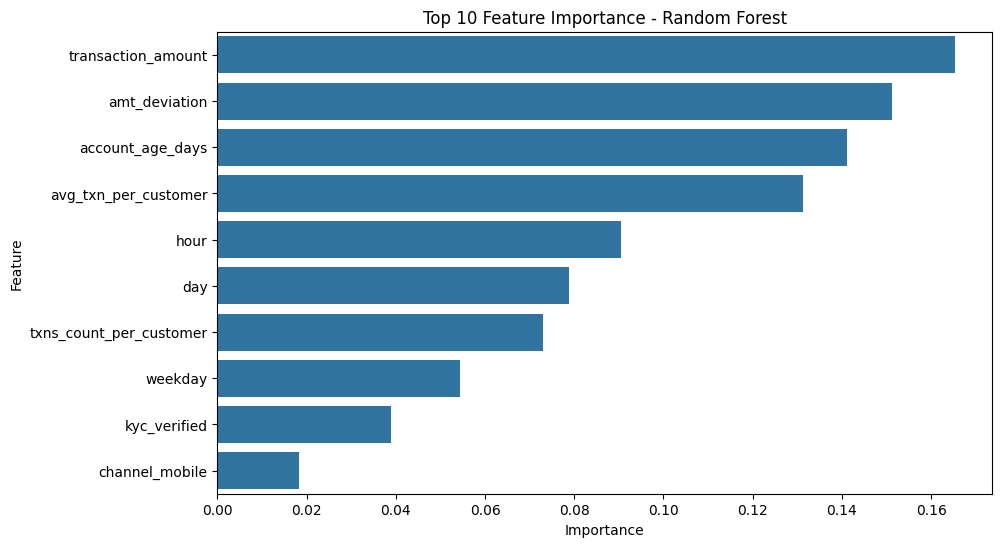

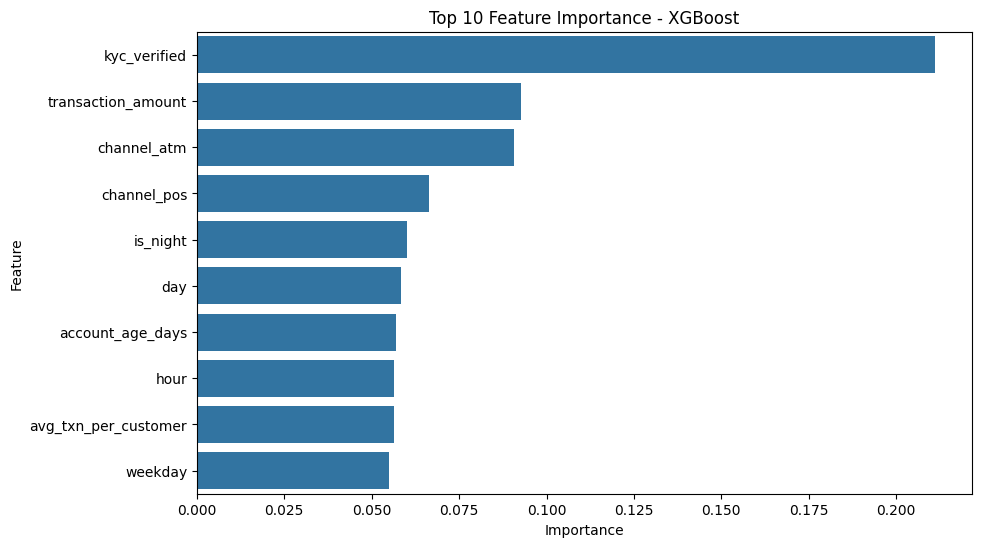

In [14]:
def plot_feature_importance(model, model_name):
    importance = model.feature_importances_
    features = X.columns
    
    # Create DataFrame of feature importance
    feat_imp = pd.DataFrame({
        'Feature': features,
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    
    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
    plt.title(f'Top 10 Feature Importance - {model_name}')
    plt.show()

# Plot feature importance for each model
plot_feature_importance(dt_model, "Decision Tree")
plot_feature_importance(rf_model, "Random Forest")
plot_feature_importance(xgb_model, "XGBoost")

In [16]:

from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier


Neural Network Results:
Accuracy: 0.8230
Precision: 0.1818
Recall: 0.3023
F1 Score: 0.2271


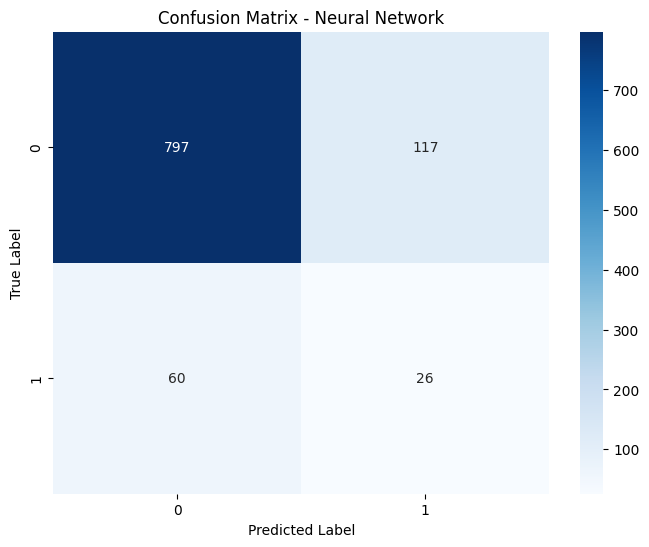

In [17]:

# 3. Neural Network (Multi-layer Perceptron)
nn_model = MLPClassifier(hidden_layer_sizes=(100, 50), 
                        max_iter=1000, 
                        random_state=42)
nn_model.fit(X, y)
nn_pred = nn_model.predict(X_test)
evaluate_model(y_test, nn_pred, "Neural Network")



Gradient Boosting Results:
Accuracy: 0.9090
Precision: 0.2222
Recall: 0.0233
F1 Score: 0.0421


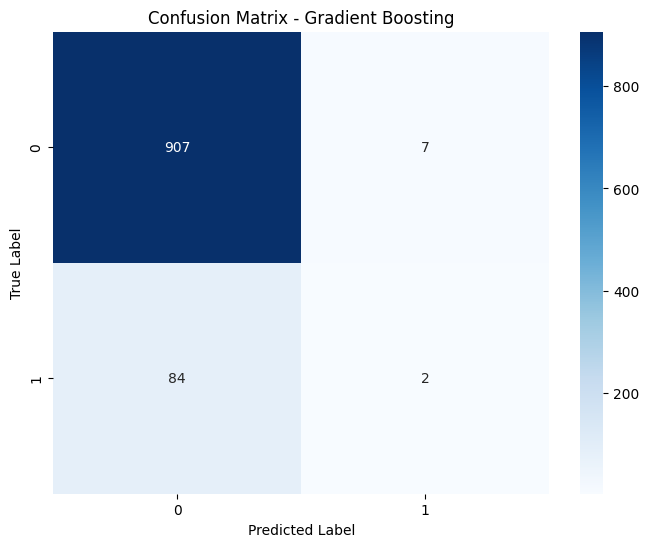

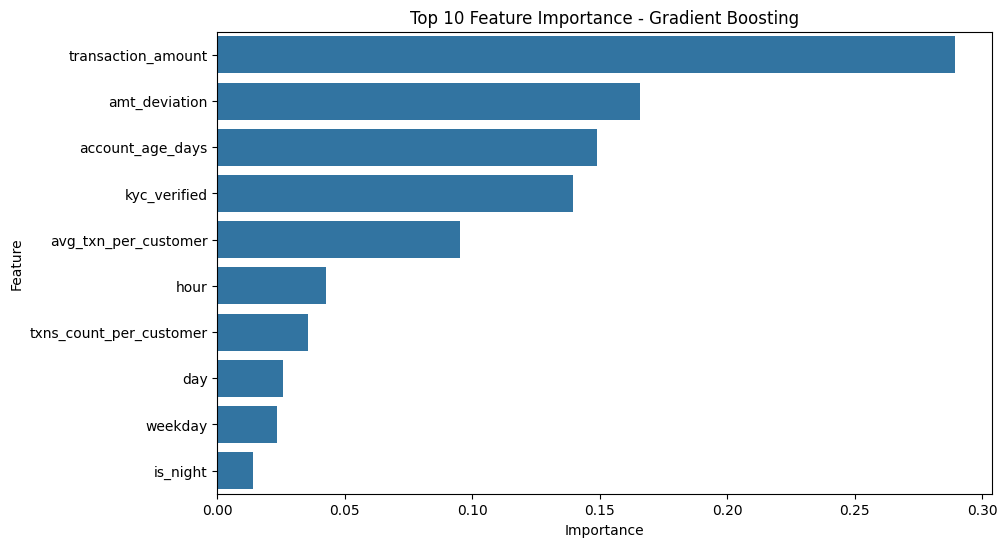

In [18]:

# Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, 
                                     learning_rate=0.1, 
                                     random_state=42)
gb_model.fit(X, y)
gb_pred = gb_model.predict(X_test)
evaluate_model(y_test, gb_pred, "Gradient Boosting")

# For models that support feature importance
for model, name in [(gb_model, "Gradient Boosting")]:
    try:
        plot_feature_importance(model, name)
    except:
        print(f"Feature importance not available for {name}")

In [20]:

from sklearn.linear_model import LogisticRegression



Logistic Regression Results:
Accuracy: 0.9100
Precision: 0.3000
Recall: 0.0349
F1 Score: 0.0625


c:\Users\Akash\OneDrive\Desktop\infsys\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


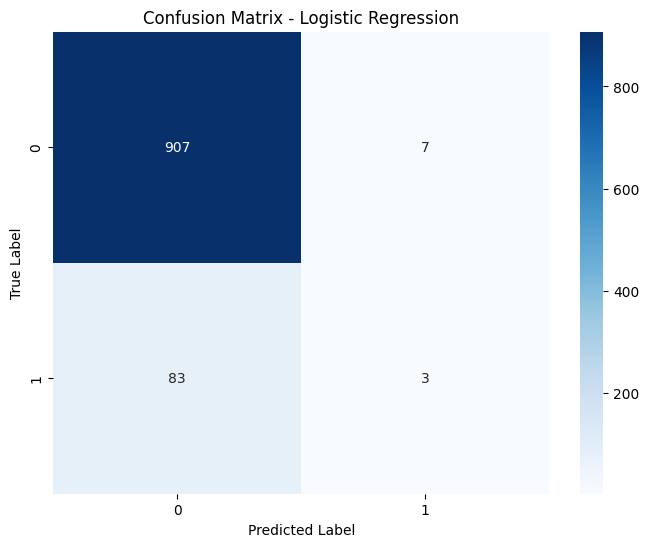

In [21]:
# Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X, y)
lr_pred = lr_model.predict(X_test)
evaluate_model(y_test, lr_pred, "Logistic Regression")



Voting Classifier Results:
Accuracy: 0.9130
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


c:\Users\Akash\OneDrive\Desktop\infsys\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


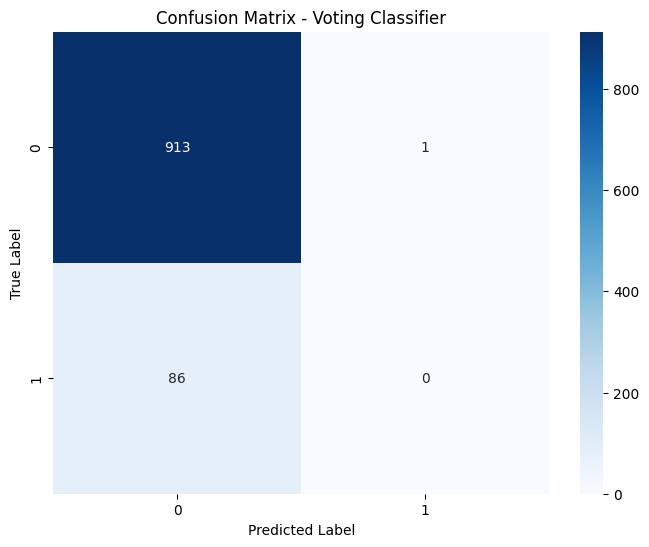

In [22]:
# Ensemble Voting Classifier
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('gb', gb_model),
        ('lr', lr_model)
    ],
    voting='hard'
)

voting_clf.fit(X, y)
voting_pred = voting_clf.predict(X_test)
evaluate_model(y_test, voting_pred, "Voting Classifier")

<Figure size 1200x600 with 0 Axes>

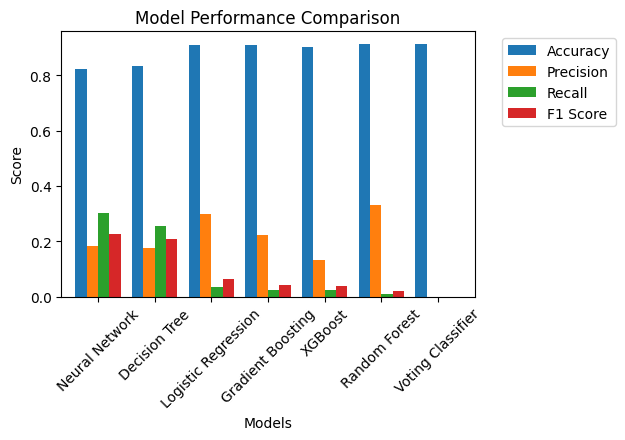


Model Performance Ranking:
                     Accuracy  Precision  Recall  F1 Score
Neural Network          0.823     0.1818  0.3023    0.2271
Decision Tree           0.834     0.1774  0.2558    0.2095
Logistic Regression     0.910     0.3000  0.0349    0.0625
Gradient Boosting       0.909     0.2222  0.0233    0.0421
XGBoost                 0.903     0.1333  0.0233    0.0396
Random Forest           0.913     0.3333  0.0116    0.0225
Voting Classifier       0.913     0.0000  0.0000    0.0000

Best Model by Metric:
----------------------------------------
Best Accuracy        : Random Forest (0.9130)
Best Precision       : Random Forest (0.3333)
Best Recall          : Neural Network (0.3023)
Best F1 Score        : Neural Network (0.2271)


In [23]:
# Create a function to get all metrics
def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

# Collect results from all models
model_results = {
    'Decision Tree': get_metrics(y_test, dt_pred),
    'Random Forest': get_metrics(y_test, rf_pred),
    'XGBoost': get_metrics(y_test, xgb_pred),
    'Neural Network': get_metrics(y_test, nn_pred),
    'Gradient Boosting': get_metrics(y_test, gb_pred),
    'Logistic Regression': get_metrics(y_test, lr_pred),
    'Voting Classifier': get_metrics(y_test, voting_pred)
}

# Create comparison DataFrame
results_df = pd.DataFrame(model_results).T
results_df = results_df.round(4)
results_df = results_df.sort_values('F1 Score', ascending=False)

# Plot comparison
plt.figure(figsize=(12, 6))
results_df.plot(kind='bar', width=0.8)
plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

# Print tabular results
print("\nModel Performance Ranking:")
print("=" * 80)
print(results_df)
print("\nBest Model by Metric:")
print("-" * 40)
for column in results_df.columns:
    best_model = results_df[column].idxmax()
    print(f"Best {column:<15} : {best_model} ({results_df[column].max():.4f})")

In [24]:
import pickle
import os

# Create a directory for models if it doesn't exist
model_dir = '../models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save the Random Forest model
model_path = os.path.join(model_dir, 'random_forest_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(rf_model, f)

print(f"Model saved to: {model_path}")

# Test loading the model
with open(model_path, 'rb') as f:
    loaded_rf_model = pickle.load(f)

# Verify the loaded model works
test_pred = loaded_rf_model.predict(X_test[:5])
print("\nVerification - Predictions from loaded model:")
print(test_pred)

Model saved to: ../models\random_forest_model.pkl

Verification - Predictions from loaded model:
[0 0 0 0 0]


In [28]:
# Example usage in API
import pickle

def load_model():
    # Use correct path separators and relative path from project root
    model_path = os.path.join("..", "models", "random_forest_model.pkl")
    try:
        with open(model_path, 'rb') as f:
            model = pickle.load(f)
            print(f"Model loaded successfully from: {os.path.abspath(model_path)}")
            return model
    except FileNotFoundError:
        raise Exception(f"Model file not found at: {os.path.abspath(model_path)}")
    except Exception as e:
        raise Exception(f"Error loading model: {str(e)}")

# Load model once when starting the API
try:
    model = load_model()
except Exception as e:
    print(f"Error: {str(e)}")

Model loaded successfully from: c:\Users\Akash\OneDrive\Desktop\infsys\LLM_BATCH_3_BACKEND_TEAM_B\models\random_forest_model.pkl


In [29]:
import os
model_path = os.path.join("..", "models", "random_forest_model.pkl")
print(f"Model file exists: {os.path.exists(os.path.abspath(model_path))}")
print(f"Full path: {os.path.abspath(model_path)}")

Model file exists: True
Full path: c:\Users\Akash\OneDrive\Desktop\infsys\LLM_BATCH_3_BACKEND_TEAM_B\models\random_forest_model.pkl


In [38]:
import pickle
import os
import numpy as np
import pandas as pd

def load_model():
    model_path = os.path.join('..', 'models', 'random_forest_model.pkl')
    with open(model_path, 'rb') as f:
        return pickle.load(f)

def predict_fraud(transaction_data):
    """
    Predict if a transaction is fraudulent
    
    Expected features:
    - transaction_amount
    - account_age_days
    - kyc_status
    - channel_atm, channel_mobile, channel_pos, channel_web
    - hour, day, weekday
    - avg_txn_per_customer
    - txns_count_per_customer
    - amt_deviation
    - high_amount_flag
    - is_night
    - is_weekend
    """
    try:
        # Load model
        model = load_model()
        
        # Convert data to DataFrame if it's a dict
        if isinstance(transaction_data, dict):
            transaction_data = pd.DataFrame([transaction_data])
            
        # Make prediction
        prediction = model.predict(transaction_data)[0]
        probability = model.predict_proba(transaction_data)[0][1]
        
        return {
            'is_fraud': bool(prediction),
            'fraud_probability': float(probability),
            'risk_level': 'High' if probability > 0.7 else 'Medium' if probability > 0.3 else 'Low'
        }
        
    except Exception as e:
        raise Exception(f"Prediction error: {str(e)}")

In [34]:
# from fastapi import APIRouter, HTTPException
# from pydantic import BaseModel
# from services.fraud_detection import predict_fraud

# router = APIRouter()

# class TransactionData(BaseModel):
#     transaction_amount: float
#     account_age_days: int
#     kyc_status: int
#     channel_mobile: int
#     channel_web: int
#     channel_atm: int
#     channel_pos: int
#     hour: int
#     day: int
#     weekday: int
#     avg_txn_per_customer: float
#     txns_count_per_customer: int
#     amt_deviation: float
#     high_amount_flag: int
#     is_night: int
#     is_weekend: int

# @router.post("/predict")
# async def predict_transaction(data: TransactionData):
#     try:
#         result = predict_fraud(data.dict())
#         return result
#     except Exception as e:
#         raise HTTPException(status_code=500, detail=str(e))

In [40]:
# Add this code to check feature names
print("Training Features:")
print(X.columns.tolist())

Training Features:
['kyc_verified', 'account_age_days', 'transaction_amount', 'hour', 'day', 'weekday', 'channel_atm', 'channel_mobile', 'channel_pos', 'channel_web', 'avg_txn_per_customer', 'txns_count_per_customer', 'amt_deviation', 'high_amount_flag', 'is_night', 'is_weekend']


In [43]:
# Example transaction data with correct feature names and order
test_transaction = {
    "kyc_verified": 1,              # Changed from kyc_status
    "account_age_days": 365,
    "transaction_amount": 0.15,
    "hour": 14,
    "day": 15,
    "weekday": 2,
    "channel_atm": 0,
    "channel_mobile": 1,
    "channel_pos": 0,
    "channel_web": 0,
    "avg_txn_per_customer": 0.12,
    "txns_count_per_customer": 5,
    "amt_deviation": 0.03,
    "high_amount_flag": 0,
    "is_night": 0,
    "is_weekend": 0
}

# Create DataFrame with correct column order
test_df = pd.DataFrame([test_transaction])[X.columns]

# Make prediction
prediction = loaded_rf_model.predict(test_df)[0]
probability = loaded_rf_model.predict_proba(test_df)[0][1]

# Print results
print("\nPrediction Results:")
print("-" * 20)
print(f"Is Fraud: {bool(prediction)}")
print(f"Fraud Probability: {probability:.4f}")
print(f"Risk Level: {'High' if probability > 0.7 else 'Medium' if probability > 0.3 else 'Low'}")


Prediction Results:
--------------------
Is Fraud: False
Fraud Probability: 0.1600
Risk Level: Low


In [47]:
import json
def transform_transaction_data(raw_input):
    """Transform raw JSON input into model-compatible format"""
    
    # Map channel to one-hot encoding
    channel_mapping = {
        'ATM': {'channel_atm': 1, 'channel_mobile': 0, 'channel_pos': 0, 'channel_web': 0},
        'MOBILE': {'channel_atm': 0, 'channel_mobile': 1, 'channel_pos': 0, 'channel_web': 0},
        'POS': {'channel_atm': 0, 'channel_mobile': 0, 'channel_pos': 1, 'channel_web': 0},
        'WEB': {'channel_atm': 0, 'channel_mobile': 0, 'channel_pos': 0, 'channel_web': 1}
    }
    
    # Extract timestamp components
    timestamp = pd.to_datetime(raw_input['timestamp'])
    
    transformed_data = {
        "kyc_verified": raw_input.get('kyc_verified', 0),
        "account_age_days": raw_input.get('account_age_days', 0),
        "transaction_amount": raw_input.get('transaction_amount', 0),
        "hour": timestamp.hour,
        "day": timestamp.day,
        "weekday": timestamp.weekday(),
        "avg_txn_per_customer": 0.0,  # You might want to calculate this
        "txns_count_per_customer": 0,  # You might want to calculate this
        "amt_deviation": 0.0,         # You might want to calculate this
        "high_amount_flag": 1 if raw_input.get('transaction_amount', 0) > 1000 else 0,
        "is_night": 1 if timestamp.hour >= 20 or timestamp.hour < 6 else 0,
        "is_weekend": 1 if timestamp.weekday() >= 5 else 0
    }
    
    # Add channel one-hot encoding
    channel_data = channel_mapping.get(raw_input.get('channel', 'ATM'), 
                                     channel_mapping['ATM'])
    transformed_data.update(channel_data)
    
    return transformed_data

# Test the transformation
raw_input = {
    "customer_id": "C12345",
    "kyc_verified": 1,
    "account_age_days": 200,
    "transaction_amount": 5000,
    "channel": "ATM",
    "timestamp": "2023-11-09 14:30:00"
}

# Transform and predict
transformed_data = transform_transaction_data(raw_input)
test_df = pd.DataFrame([transformed_data])[X.columns]

# Make prediction
prediction = loaded_rf_model.predict(test_df)[0]
probability = loaded_rf_model.predict_proba(test_df)[0][1]

# Print results
print("\nInput Transaction:")
print("-" * 20)
print(json.dumps(raw_input, indent=2))

print("\nPrediction Results:")
print("-" * 20)
print(f"Is Fraud: {bool(prediction)}")
print(f"Fraud Probability: {probability:.4f}")
print(f"Risk Level: {'High' if probability > 0.7 else 'Medium' if probability > 0.3 else 'Low'}")


Input Transaction:
--------------------
{
  "customer_id": "C12345",
  "kyc_verified": 1,
  "account_age_days": 200,
  "transaction_amount": 5000,
  "channel": "ATM",
  "timestamp": "2023-11-09 14:30:00"
}

Prediction Results:
--------------------
Is Fraud: False
Fraud Probability: 0.4300
Risk Level: Medium
